# **Dataset Visualizations**

This script is used to created for 1) analysing the settings of the different datasets and 2) create figures for the report (Add citation) results section.

In [1]:
import os
import sys
import glob
import math
import random
import pathlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.gridspec as gridspec  
import matplotlib.patches as mpatches
import matplotlib.colorbar as mcolorbar
from matplotlib.colors import Normalize
from scipy.stats import entropy
from sklearn.manifold import MDS
from matplotlib.colors import ListedColormap, Normalize

scripts_dir = Path.cwd().parents[1]
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from gan_pipeline.core import custom_plots as custom_plots
custom_plots.apply_custom_plotting_flavor()

# Attempt to load pyvista for 3D plotting
try:
    import pyvista as pv
    pv.set_jupyter_backend('static')
    HAS_PYVISTA = True
except ImportError:
    HAS_PYVISTA = False
    print("Warning: 'pyvista' not installed. 3D renderings will be skipped or saved off-screen.")

In [2]:
# --- Centralized Configuration ---
FACIES_PROPERTIES = {
    0:  {'color': "#ff0000", 'name': "Undefined"},
    1:  {'color': "#f1970f", 'name': "Channel Lag"},
    2:  {'color': "#f3dd12", 'name': "Point Bar"},
    3:  {'color': "#af8f00", 'name': "Sand Plug"},
    4:  {'color': "#fffc65", 'name': "Crevasse Splay Core"},
    5:  {'color': "#ffd986", 'name': "Crevasse Channel"},
    6:  {'color': "#ff9853", 'name': "Crevasse Splay Delta"},
    7:  {'color': "#27ae60", 'name': "Levee"},
    8:  {'color': "#33ff00", 'name': "Overbank"},
    9:  {'color': "#fff7db", 'name': "Mud Plug"},
    10: {'color': "#7a7d80", 'name': "Hemipelagic Plug"},
    11: {'color': "#d862f0", 'name': "Wetland"},
    12: {'color': "#8dd5e7", 'name': "Draping"},
    13: {'color': "#3498db", 'name': "Pelagic"}
}

FONT_TITLE = 6      # Main headers, panel names, column indicators
FONT_LABEL = 6       # Axis descriptions, shared side-labels, legend titles
FONT_TICK  = 6       # Tick readouts, numeric inline text values, legend items

In [90]:
class FLUMYDatasetAnalyzer:
    def __init__(self, base_dir, output_dir):
        self.base_dir = Path(base_dir)
        self.output_dir = Path(output_dir)
        self.training_dir = self.base_dir / "datasets" / "training"
        
        # Identify the target 3 settings
        self.settings = [
            "setting_1_nexus_1000_samples_ntg_67_chdepth_6_isbx_100",
            "setting_2_nexus_1000_samples_ntg_67_chdepth_5_isbx_80",
            "setting_3_nexus_1000_samples_ntg_67_chdepth_7_isbx_120"
        ]
        
        for s in self.settings:
            os.makedirs(self.output_dir / s, exist_ok=True)
            
        self.cmap_colors = [FACIES_PROPERTIES[i]['color'] for i in range(14)]
        self.facies_cmap = ListedColormap(self.cmap_colors)

        # Grouped configuration
        self.grouped_cmap = ListedColormap(['#f1970f', '#fffc65', '#33ff00'])  # Channel, Crevasse/Levee, Floodplain

    def extract_facies_percentages(self):
        print("\n=== Generating Output 1: Facies Volume Percentages Table ===")
        records = []
        
        for setting in self.settings:
            facies_dir = self.training_dir / setting / "samples" / "facies"
            files = sorted(list(facies_dir.glob("*.npy")))
            
            if not files:
                print(f"Warning: No samples found for {setting}")
                continue
                
            # FIXED: Changed dtype from np.int8 to np.int64 to prevent overflow when summing 1000 grids
            total_counts = np.zeros(14, dtype=np.int64)
            print(f"Processing 1000 realizations for {setting}...")
            
            for f in files[:1000]:
                grid = np.load(f)
                counts = np.bincount(grid.ravel(), minlength=14)
                total_counts += counts
                
            total_voxels = total_counts.sum()
            percentages = (total_counts / total_voxels) * 100
            
            row = {'Setting': setting.split('_nexus')[0].replace('_', ' ').title()}
            for idx in range(14):
                row[FACIES_PROPERTIES[idx]['name']] = round(percentages[idx], 4)
            records.append(row)
            
        df = pd.DataFrame(records)
        csv_path = self.output_dir / "facies_percentages_table.csv"
        df.to_csv(csv_path, index=False)
        print(f"\nSaved Facies Percentage Table to: {csv_path}")
        print(df.to_string(index=False))
        return df

    def save_grouped_samples(self):
        print("\n=== Saving Grouped Samples ===")
        mapping = np.zeros(14, dtype=np.int8)
        mapping[1:4] = 0   # 1, 2, 3
        mapping[4:8] = 1   # 4, 5, 6, 7
        mapping[8:14] = 2  # 8, 9, 10, 11, 12, 13
        
        for setting in self.settings:
            facies_dir = self.training_dir / setting / "samples" / "facies"
            grouped_dir = self.training_dir / setting / "samples" / "grouped_facies"
            os.makedirs(grouped_dir, exist_ok=True)
            files = sorted(list(facies_dir.glob("*.npy")))
            
            if not files:
                continue
                
            print(f"Saving grouped samples for {setting}...")
            for f in files:
                grid = np.load(f)
                grouped_grid = mapping[grid]
                np.save(grouped_dir / f.name, grouped_grid)
        print("Grouped samples saved successfully.")

    def generate_3d_entropy_plots(self, num_realizations=100):
        print("\n=== Generating Output 2: Three 3D Ensemble Entropy Plots ===")
        if not HAS_PYVISTA:
            print("Skipping 3D rendering: PyVista is required.")
            return

        mapping = np.zeros(14, dtype=np.int8)
        mapping[1:4] = 0   # 1, 2, 3
        mapping[4:8] = 1   # 4, 5, 6, 7
        mapping[8:14] = 2  # 8, 9, 10, 11, 12, 13

        for setting in self.settings:
            facies_dir = self.training_dir / setting / "samples" / "facies"
            files = sorted(list(facies_dir.glob("*.npy")))[:num_realizations]
            
            if not files: continue
            
            ref_grid = np.load(files[0])
            nz, ny, nx = ref_grid.shape
            
            # Aggregate voxel counts across ensemble using grouped facies (3 groups)
            counts_4d = np.zeros((3, nz, ny, nx), dtype=np.float32)
            for f in files:
                grid = np.load(f)
                grouped_grid = mapping[grid]
                for facies_val in range(3):
                    counts_4d[facies_val] += (grouped_grid == facies_val)
                    
            probs = counts_4d / len(files)
            
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                entropy_map = entropy(probs, base=2, axis=0)
                
            # Normalize by theoretical max entropy log2(3)
            h_max = np.log2(3)
            entropy_map_norm = entropy_map / h_max
            
            pv_grid = pv.ImageData()
            pv_grid.dimensions = (nx + 1, ny + 1, nz + 1)
            pv_grid.cell_data['Entropy'] = entropy_map_norm.transpose(2, 1, 0).flatten(order='F')
            
            plotter = pv.Plotter(off_screen=True, window_size=(1300, 900))
            plotter.add_mesh(
                pv_grid,
                scalars='Entropy',
                cmap='magma',
                clim=[0.0, 1.0],
                ambient=0.3,
                diffuse=0.7,
                show_scalar_bar=False
            )
            plotter.view_isometric()
            plotter.camera.elevation -= 10
            plotter.reset_camera()
            plotter.camera.zoom(1.3)
            
            out_img_path = self.output_dir / setting / f"3D_ensemble_entropy_{setting}.png"
            plotter.show(screenshot=str(out_img_path))
            print(f"Saved 3D Entropy Model to: {out_img_path}")

    def generate_3d_facies_plots(self):
        print("\n=== Generating Output 3: Six 3D Realization Facies Plots ===")
        if not HAS_PYVISTA:
            print("Skipping 3D rendering: PyVista is required.")
            return

        mapping = np.zeros(14, dtype=np.int8)
        mapping[1:4] = 0   # 1, 2, 3
        mapping[4:8] = 1   # 4, 5, 6, 7
        mapping[8:14] = 2  # 8, 9, 10, 11, 12, 13

        for setting in self.settings:
            facies_dir = self.training_dir / setting / "samples" / "facies"
            files = sorted(list(facies_dir.glob("*.npy")))
            if not files: continue
            
            selected_files = random.sample(files, 2)
            
            for f_idx, file_path in enumerate(selected_files):
                data_3d = np.load(file_path)
                grouped_data = mapping[data_3d]
                nz, ny, nx = grouped_data.shape
                
                pv_grid = pv.ImageData()
                pv_grid.dimensions = (nx + 1, ny + 1, nz + 1)
                pv_grid.cell_data['Facies'] = grouped_data.transpose(2, 1, 0).flatten(order='F')
                
                plotter = pv.Plotter(off_screen=True, window_size=(1300, 900))
                plotter.add_mesh(
                    pv_grid,
                    scalars='Facies',
                    cmap=self.grouped_cmap,
                    clim=[0, 2],
                    ambient=0.2,
                    diffuse=0.8,
                    show_scalar_bar=False
                )
                plotter.view_isometric()
                plotter.camera.elevation -= 10
                plotter.reset_camera()
                plotter.camera.zoom(1.3)
                
                out_img_path = self.output_dir / setting / f"3D_facies_model_realization_{f_idx+1}.png"
                plotter.show(screenshot=str(out_img_path))
                print(f"Saved 3D Facies realization plot to: {out_img_path}")

    def generate_2d_mds_plot(self, subset_size=100):
        print("\n=== Generating Output 4: 2D MDS Settings Comparison Plot ===")
        
        all_features = []
        labels = []
        
        for setting in self.settings:
            facies_dir = self.training_dir / setting / "samples" / "facies"
            files = sorted(list(facies_dir.glob("*.npy")))[:subset_size]
            setting_label = setting.split('_nexus')[0].replace('_', ' ').title()
            
            for f in files:
                grid = np.load(f)
                counts = np.bincount(grid.ravel(), minlength=14)
                props = counts / counts.sum()
                all_features.append(props)
                labels.append(setting_label)
                
        features_matrix = np.array(all_features)
        
        mds = MDS(n_components=2, dissimilarity='euclidean', random_state=42, n_jobs=-1)
        embeddings = mds.fit_transform(features_matrix)
        
        fig, ax = plt.subplots(figsize=(6, 8))
        unique_labels = sorted(list(set(labels)))
        colors = ["#f1970f", "#fffc65", "#33ff00"]
        markers = ['o', 's', '^']
        
        for i, l in enumerate(unique_labels):
            idx = [j for j, val in enumerate(labels) if val == l]
            ax.scatter(
                embeddings[idx, 0], embeddings[idx, 1],
                marker=markers[i], label=f"{l} (N={len(idx)})",
                s=35, alpha=0.8, edgecolors='white', linewidths=0.4
            )
            
        # ax.set_title("MDS Spatial Clustering", fontsize=FONT_TITLE, pad=10)
        # ax.set_xlabel('Dimension 1', fontsize=FONT_LABEL)
        # ax.set_ylabel('Dimension 2', fontsize=FONT_LABEL)
        ax.tick_params(axis='both', labelsize=FONT_TICK)
        ax.grid(color='#BFBFBF', alpha=0.4, linestyle='--', linewidth=0.5)
        ax.legend(loc='best', fontsize=FONT_TICK, frameon=True)
        
        out_mds_path = self.output_dir / "flumy_settings_mds_comparison.png"
        plt.savefig(out_mds_path, bbox_inches='tight', dpi=400)
        print(f"Saved 2D MDS Plot to: {out_mds_path}")
        plt.show()

    def calculate_mean_entropy(self, setting, num_realizations=150):
        """Calculates mean spatial uncertainty using identical 3-group schema limits."""
        try:
            facies_dir = self.training_dir / setting / "samples" / "facies"
            files = sorted(list(facies_dir.glob("*.npy")))[:num_realizations]
            if not files: return None
            
            ref_grid = np.load(files[0])
            nz, ny, nx = ref_grid.shape
            
            mapping = np.zeros(14, dtype=np.int8)
            mapping[1:4] = 0
            mapping[4:8] = 1
            mapping[8:14] = 2

            probs = np.zeros((3, nz, ny, nx), dtype=np.float32)
            for f in files:
                grid = np.load(f)
                grouped_grid = mapping[grid]
                for v in range(3):
                    probs[v] += (grouped_grid == v)
            probs /= len(files)
            
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                entropy_map = entropy(probs, base=2, axis=0)
            
            h_max = np.log2(3)
            if h_max > 0:
                entropy_map /= h_max
                
            return float(np.mean(entropy_map))
        except Exception as e:
            print(f"[{setting}] Error resolving mean entropy -> {e}")
            return None

    def plot_render_sample(self, ax, plot_dir, search_pattern, error_msg, mean_metric_text=None):
        """Safely locates and embeds generated PNG models with label overlays."""
        search_path = os.path.join(plot_dir, search_pattern)
        matching_files = glob.glob(search_path)
        
        if matching_files:
            latest_file_path = max(matching_files, key=os.path.getctime)
            img = mpimg.imread(latest_file_path)
            ax.imshow(img, aspect='equal')
            if mean_metric_text:
                ax.text(0.5, 1.05, mean_metric_text, fontsize=FONT_TICK, color='#595959', 
                        ha='center', va='baseline', transform=ax.transAxes)
        else:
            ax.text(0.5, 0.5, error_msg, ha='center', va='center', color='red', fontsize=FONT_TICK)
        ax.axis('off')

    def plot_shared_label(self, ax, label, is_vertical=False, pad=12):
        """Generates hidden label planes across empty underlying axes grids."""
        ax.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)
        ax.grid(False)
        if is_vertical:
            ax.set_ylabel(label, fontsize=FONT_LABEL, labelpad=pad)
        else:
            ax.set_xlabel(label, fontsize=FONT_LABEL, labelpad=pad)

    def generate_combined_gridspec(self):
        """Output 5: Creates a cohesive half-A4 summary layout using absolute typographical lockstep."""
        print("\n=== Generating Output 5: Combined Gridspec Summary ===")
        
        n_runs = len(self.settings)
        fig = plt.figure(figsize=(8.27, 4.2)) # Slightly increased height for the extra row
        
        # FIX: Changed to 4 rows and added height_ratios so row 3 (index 3) is a slim slot for legend/cbar
        gs = gridspec.GridSpec(4, 5, figure=fig, width_ratios=[0.5, 0.5, 0.5, 1, 1], height_ratios=[1, 1, 1, 0.15])
        gs.update(hspace=0.35, wspace=0.25, bottom=0.1, top=0.92, left=0.06, right=0.94)

        # 1. MDS Plot Integration (Spans all 4 rows now to stay vertically centered)
        ax_mds = fig.add_subplot(gs[0:4, 0:3])
        mds_path = self.output_dir / "flumy_settings_mds_comparison.png"
        if mds_path.exists():
            img = mpimg.imread(mds_path)
            ax_mds.imshow(img, aspect='equal')
        ax_mds.set_xticks([])  # Remove X tick marks
        ax_mds.set_yticks([])  # Remove Y tick marks
        for spine in ax_mds.spines.values():
            spine.set_visible(False)  # Hide the outer bounding box borders
            
        ax_mds.set_title("MDS Parameter Space", fontsize=FONT_TITLE, pad=20, loc='left')
        ax_mds.set_ylabel("Dimension 1", fontsize=6, labelpad=5) # Added minor padding
        ax_mds.set_xlabel("Dimension 2", fontsize=6, labelpad=5)
        
        # 2. 3D Model Panels Iteration
        setting_names = [s.split('_nexus')[0].replace('_', ' ').title() for s in self.settings]
        
        for i, setting in enumerate(self.settings):
            setting_dir = self.output_dir / setting
            
            # --- 3D Facies Realization 1 (Column 3) ---
            ax_facies1 = fig.add_subplot(gs[i, 3])
            self.plot_render_sample(ax_facies1, str(setting_dir), "3D_facies_model_realization_1.png", "Facies 1 Missing")
            ax_facies1.set_box_aspect(0.75)
            
            ax_facies1.text(
                -0.15, 0.5,          # X position pushes it left of the box, Y=0.5 centers it vertically
                setting_names[i], 
                fontsize=6, 
                color='#595959',
                va='center',         # Center alignment vertically
                ha='right',          # Right alignment so varying text lengths don't collide with the image
                rotation='vertical', # Rotates it 90 degrees like a native ylabel
                transform=ax_facies1.transAxes
            )

            if i == 0:
                ax_facies1.set_title("Random sample", loc='center', fontsize=FONT_TITLE, pad=20)
                
            # --- 3D Ensemble Entropy Plot (Column 5) ---
            ax_entropy = fig.add_subplot(gs[i, 4])
            mean_entropy_val = self.calculate_mean_entropy(setting)    
            entropy_text = f"mean $H$ = {mean_entropy_val:.3f}" if mean_entropy_val is not None else ""
            
            self.plot_render_sample(ax_entropy, str(setting_dir), f"3D_ensemble_entropy_{setting}.png", "Entropy Missing", mean_metric_text=entropy_text)
            ax_entropy.set_box_aspect(0.75)
            
            if i == 0:
                ax_entropy.set_title("Ensemble Entropy", fontsize=FONT_TITLE, pad=20)

        # FIX: Moved Legend to the new, dedicated 4th row slot (gs[3, 3])
        ax_leg = fig.add_subplot(gs[3, 3], frameon=False)
        ax_leg.axis('off')
        legend_elements = [
            mpatches.Patch(color='#f1970f', label='Channel-related'),
            mpatches.Patch(color='#fffc65', label='Crevasse/Levee'),
            mpatches.Patch(color='#33ff00', label='Floodplain'),
        ]
        ax_leg.legend(handles=legend_elements, loc='center', ncol=1, # Stacked vertically fits a narrow column better
                    fontsize=5.5, title="Grouped Facies Legend", title_fontsize=6,
                    frameon=True, facecolor='white', edgecolor='#E0E0E0')
        
        ax_cbar = fig.add_subplot(gs[3, 4])
        
        # --- NEW: SIGNIFICANTLY SHRINK AND CENTER THE COLORBAR AXIS ---
        pos = ax_cbar.get_position()
        new_width = pos.width * 0.6     # Scale down width to 60% of the grid cell
        new_height = pos.height * 0.25  # Scale down height to 25% of the grid cell (makes it slim)
        
        new_x = pos.x0 + (pos.width - new_width) / 2
        new_y = pos.y0 + (pos.height - new_height) / 2
        ax_cbar.set_position([new_x, new_y, new_width, new_height])
        
        norm = Normalize(vmin=0.0, vmax=1.0)
        cb = mcolorbar.ColorbarBase(ax_cbar, cmap='magma', norm=norm, orientation='horizontal')
        
        # Reduced labelpad so the text stays tucked close to the smaller bar
        cb.set_label('Normalized Entropy ($H$)', fontsize=FONT_LABEL, labelpad=2)
        cb.ax.tick_params(labelsize=FONT_TICK, length=1.5, pad=1.5)
        cb.outline.set_edgecolor('#E0E0E0')
        cb.outline.set_linewidth(0.5)

        out_path = self.output_dir / "combined_gridspec_summary.png"
        plt.savefig(out_path, dpi=500, bbox_inches='tight', facecolor='white')
        print(f"Saved Combined Gridspec Summary Dashboard to: {out_path}")
        plt.show()

In [91]:
BASE_DIR = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM"
OUTPUT_DIR = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots"
    
analyzer = FLUMYDatasetAnalyzer(base_dir=BASE_DIR, output_dir=OUTPUT_DIR)

# 0. saving grouped samples
# analyzer.save_grouped_samples()

# # 1. Output Table with Facies Percentages
# analyzer.extract_facies_percentages()
    
# # 2. Output Three 3D Ensemble Entropy Maps
# analyzer.generate_3d_entropy_plots(num_realizations=150)
    
# 3. Output Six individual 3D Realization Facies Plots
# analyzer.generate_3d_facies_plots()

# analyzer.generate_2d_mds_plot(subset_size=100)


## **Figure 4.1**

Comparison of Setting 1, 2 and 3 with 2D MDS plot, 6 3D facies samples (2 of each setting) and the three entropy plots.


=== Generating Output 5: Combined Gridspec Summary ===
Saved Combined Gridspec Summary Dashboard to: C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\preprocessing_plots\combined_gridspec_summary.png


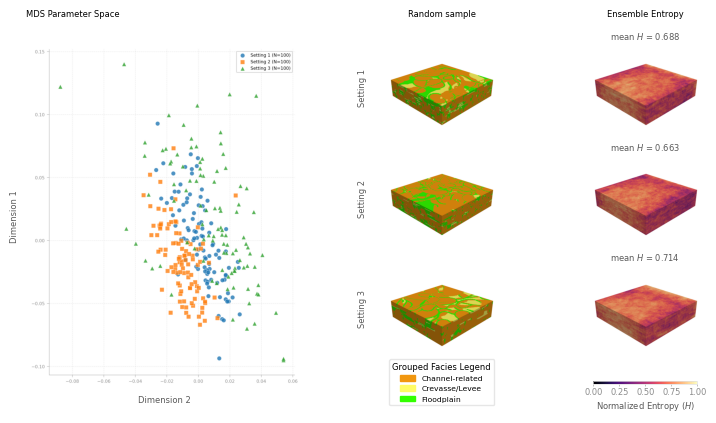

In [92]:
analyzer.generate_combined_gridspec()